In [1]:
import random

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility for any Python and NumPy randomness used in this notebook.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [2]:
TICKERS = [
    "AAPL",
    "MSFT",
    "GOOGL",
    "AMZN",
    "META",
    "NVDA",
    "JPM",
    "XOM",
    "JNJ",
    "KO"
]

prices = yf.download(
    TICKERS,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

prices.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171757,15.4260,26.227922,75.737373,45.838097,29.215927,77.705750,39.607178,0.481884,56.777912
2015-01-05,23.490795,15.1095,25.728178,75.208397,44.415051,29.215927,76.457710,39.242966,0.473745,55.224339
2015-01-06,23.493010,14.7645,25.093222,74.838867,43.263432,29.437782,75.427582,38.666977,0.459382,54.930759
2015-01-07,23.822437,14.9210,25.019426,76.490982,43.329449,29.805246,75.427582,39.158260,0.458185,55.487354
2015-01-08,24.737749,15.0230,25.106592,77.092415,44.297699,30.165749,77.438339,40.310215,0.475420,56.410931


In [3]:
print(prices.shape)
print(prices.index.min())
print(prices.index.max())
print(prices.isna().sum())

(2766, 10)
2015-01-02 00:00:00
2025-12-31 00:00:00
Ticker
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
KO       0
META     0
MSFT     0
NVDA     0
XOM      0
dtype: int64


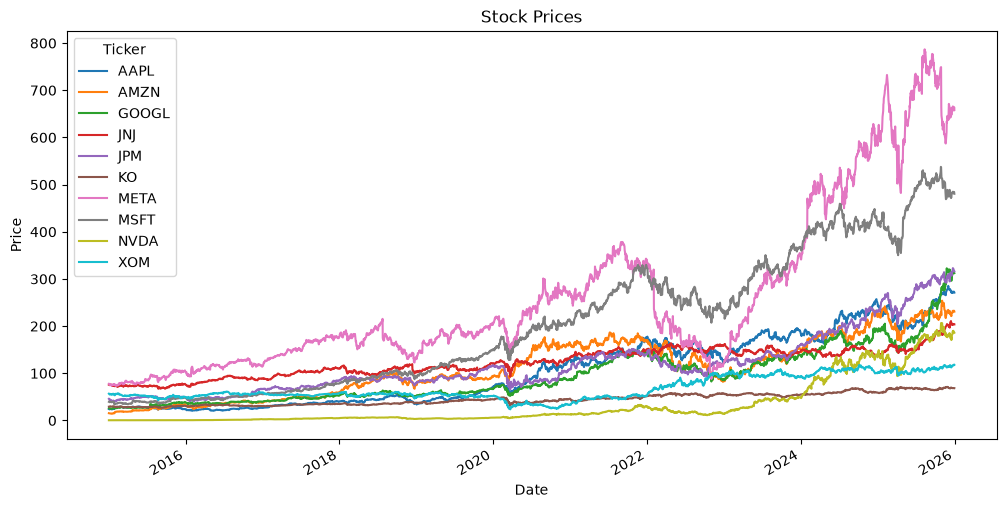

In [4]:
prices.plot(figsize=(12, 6))
plt.title("Stock Prices")
plt.ylabel("Price")
plt.show()

In [5]:
weekly_prices = prices.resample("W-FRI").last()
weekly_prices.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-02,24.171757,15.4260,26.227922,75.737373,45.838097,29.215927,77.705750,39.607178,0.481884,56.777912
2015-01-09,24.764277,14.8465,24.800011,76.041702,43.527493,29.832970,77.002487,39.971405,0.477335,56.331409
2015-01-16,23.433315,14.5370,25.282421,75.389542,41.026169,29.486322,74.466782,39.166729,0.477814,55.732014
2015-01-23,24.978735,15.6195,26.842079,74.056229,41.576305,30.027096,77.091644,39.962933,0.495768,55.591347
2015-01-30,25.902884,17.7265,26.624153,72.563530,39.889194,28.543421,75.189850,34.220066,0.459621,53.468979


In [6]:
weekly_returns = weekly_prices.pct_change()
weekly_returns = weekly_returns.dropna()
weekly_returns.head()

Ticker,AAPL,AMZN,GOOGL,JNJ,JPM,KO,META,MSFT,NVDA,XOM
Date,,,,,,,,,,
2015-01-09,0.024513,-0.037566,-0.054442,0.004018,-0.050408,0.021120,-0.009050,0.009196,-0.009439,-0.007864
2015-01-16,-0.053745,-0.020847,0.019452,-0.008576,-0.057465,-0.011620,-0.032930,-0.020131,0.001003,-0.010641
2015-01-23,0.065950,0.074465,0.061689,-0.017686,0.013409,0.018340,0.035249,0.020329,0.037575,-0.002524
2015-01-30,0.036997,0.134895,-0.008119,-0.020156,-0.040579,-0.049411,-0.024669,-0.143705,-0.072912,-0.038178
2015-02-06,0.019114,0.055708,-0.006827,0.009587,0.064546,0.006801,-0.018970,0.049753,0.062500,0.054550


In [7]:
print(weekly_returns.shape)
print(weekly_returns.describe())

(574, 10)
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000  574.000000  574.000000  574.000000   
mean      0.004950    0.005603    0.005071    0.002002    0.004041   
std       0.038172    0.042036    0.038947    0.023539    0.036654   
min      -0.175307   -0.144583   -0.120286   -0.107231   -0.196420   
25%      -0.016868   -0.017605   -0.016887   -0.012206   -0.014772   
50%       0.005341    0.004609    0.005234    0.002241    0.005479   
75%       0.026640    0.029338    0.025930    0.016735    0.024922   
max       0.147331    0.185163    0.258060    0.089396    0.222606   

Ticker          KO        META        MSFT        NVDA         XOM  
count   574.000000  574.000000  574.000000  574.000000  574.000000  
mean      0.001815    0.004899    0.004892    0.012380    0.001983  
std       0.025318    0.048363    0.032785    0.063096    0.037565  
min      -0.209821   -0.236982   -0.143705   -0.200515   -0.200671  
25%      -0.01

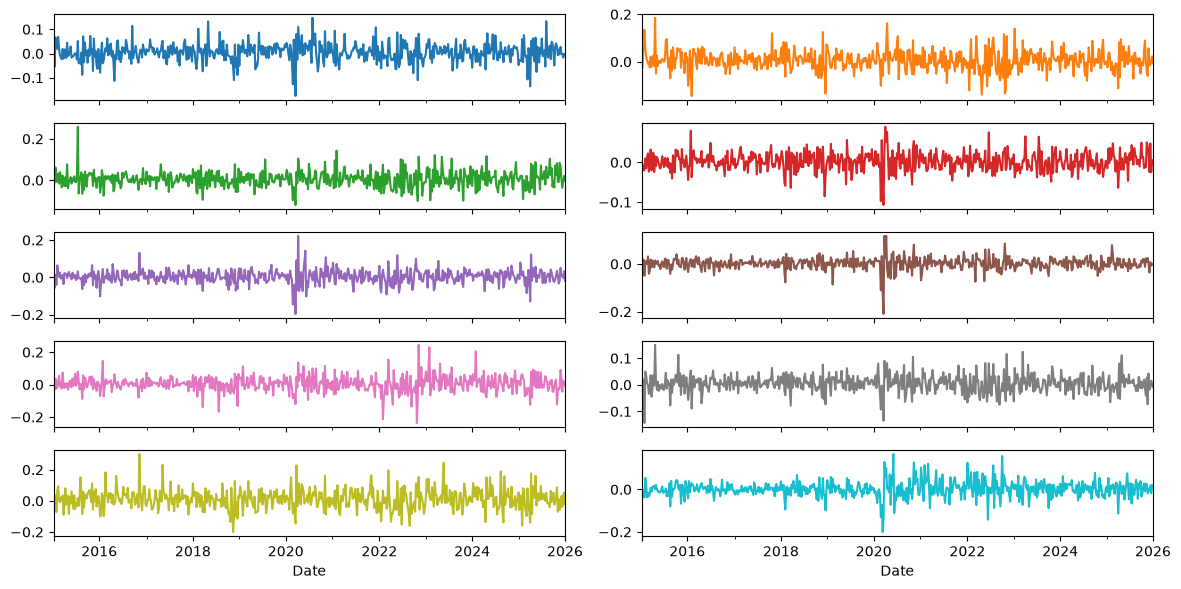

In [8]:
weekly_returns.plot(
    figsize=(12, 6),
    subplots=True,
    layout=(5, 2),
    legend=False
)

plt.tight_layout()
plt.show()

In [9]:
correlation = weekly_returns.corr()
print(correlation.round(2))

Ticker  AAPL  AMZN  GOOGL   JNJ   JPM    KO  META  MSFT  NVDA   XOM
Ticker                                                             
AAPL    1.00  0.48   0.54  0.31  0.36  0.37  0.41  0.57  0.48  0.18
AMZN    0.48  1.00   0.58  0.15  0.31  0.14  0.50  0.61  0.52  0.11
GOOGL   0.54  0.58   1.00  0.24  0.36  0.31  0.51  0.62  0.45  0.21
JNJ     0.31  0.15   0.24  1.00  0.33  0.51  0.13  0.31  0.14  0.29
JPM     0.36  0.31   0.36  0.33  1.00  0.43  0.31  0.38  0.36  0.51
KO      0.37  0.14   0.31  0.51  0.43  1.00  0.21  0.38  0.18  0.36
META    0.41  0.50   0.51  0.13  0.31  0.21  1.00  0.55  0.42  0.12
MSFT    0.57  0.61   0.62  0.31  0.38  0.38  0.55  1.00  0.60  0.19
NVDA    0.48  0.52   0.45  0.14  0.36  0.18  0.42  0.60  1.00  0.16
XOM     0.18  0.11   0.21  0.29  0.51  0.36  0.12  0.19  0.16  1.00


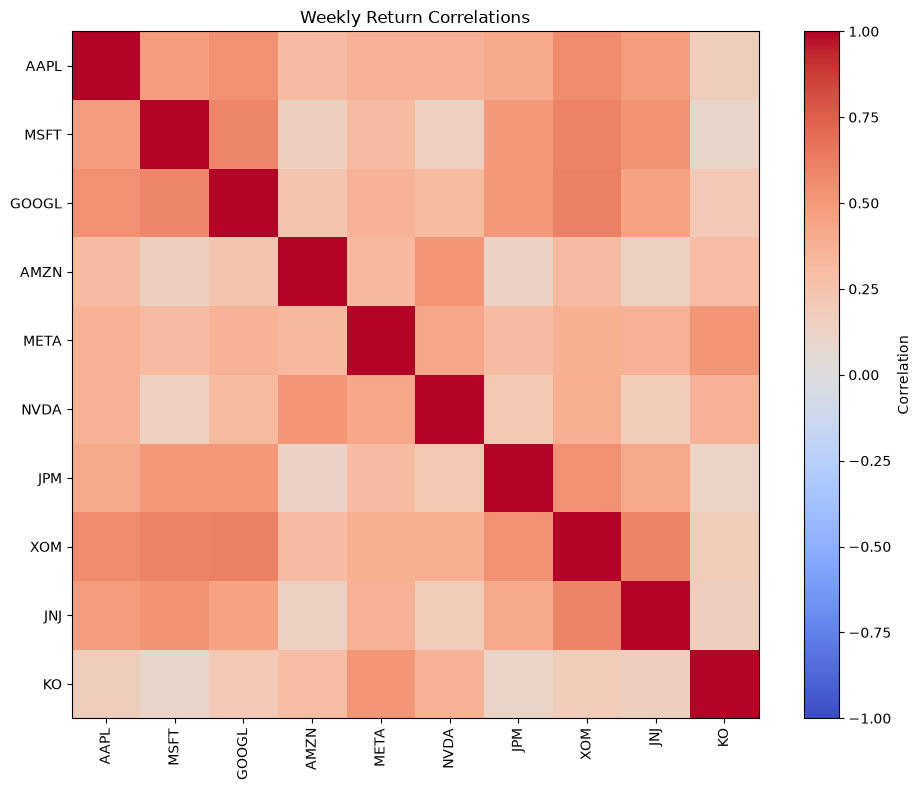

In [10]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(
    range(len(TICKERS)),
    TICKERS,
    rotation=90
)

plt.yticks(
    range(len(TICKERS)),
    TICKERS
)

plt.colorbar(label="Correlation")

plt.title("Weekly Return Correlations")
plt.tight_layout()
plt.show()

In [11]:
covariance = weekly_returns.cov()

print(covariance.round(5))

Ticker     AAPL     AMZN    GOOGL      JNJ      JPM       KO     META  \
Ticker                                                                  
AAPL    0.00146  0.00077  0.00080  0.00028  0.00051  0.00036  0.00076   
AMZN    0.00077  0.00177  0.00095  0.00015  0.00048  0.00015  0.00102   
GOOGL   0.00080  0.00095  0.00152  0.00022  0.00052  0.00031  0.00096   
JNJ     0.00028  0.00015  0.00022  0.00055  0.00028  0.00031  0.00014   
JPM     0.00051  0.00048  0.00052  0.00028  0.00134  0.00040  0.00055   
KO      0.00036  0.00015  0.00031  0.00031  0.00040  0.00064  0.00026   
META    0.00076  0.00102  0.00096  0.00014  0.00055  0.00026  0.00234   
MSFT    0.00071  0.00084  0.00079  0.00024  0.00046  0.00032  0.00086   
NVDA    0.00116  0.00139  0.00110  0.00021  0.00084  0.00029  0.00127   
XOM     0.00026  0.00017  0.00031  0.00026  0.00071  0.00034  0.00021   

Ticker     MSFT     NVDA      XOM  
Ticker                             
AAPL    0.00071  0.00116  0.00026  
AMZN    0.00084

In [12]:
print(weekly_returns.shape)
print(weekly_returns.head())
print(weekly_returns.describe())

(574, 10)
Ticker          AAPL      AMZN     GOOGL       JNJ       JPM        KO  \
Date                                                                     
2015-01-09  0.024513 -0.037566 -0.054442  0.004018 -0.050408  0.021120   
2015-01-16 -0.053745 -0.020847  0.019452 -0.008576 -0.057465 -0.011620   
2015-01-23  0.065950  0.074465  0.061689 -0.017686  0.013409  0.018340   
2015-01-30  0.036997  0.134895 -0.008119 -0.020156 -0.040579 -0.049411   
2015-02-06  0.019114  0.055708 -0.006827  0.009587  0.064546  0.006801   

Ticker          META      MSFT      NVDA       XOM  
Date                                                
2015-01-09 -0.009050  0.009196 -0.009439 -0.007864  
2015-01-16 -0.032930 -0.020131  0.001003 -0.010641  
2015-01-23  0.035249  0.020329  0.037575 -0.002524  
2015-01-30 -0.024669 -0.143705 -0.072912 -0.038178  
2015-02-06 -0.018970  0.049753  0.062500  0.054550  
Ticker        AAPL        AMZN       GOOGL         JNJ         JPM  \
count   574.000000  574.000000

In [13]:
weekly_returns.to_csv("../data/weekly_returns.csv")
weekly_prices.to_csv("../data/weekly_prices.csv")

In [14]:
# ============================================
# STEP 1: Create supervised learning dataset
# ============================================

import numpy as np
import pandas as pd

LOOKBACK = 12  # Use previous 12 weeks to predict the next week

X = []
y = []
dates = []

for i in range(LOOKBACK, len(weekly_returns)):
    
    # Previous 12 weeks of returns
    X.append(
        weekly_returns.iloc[i-LOOKBACK:i].values
    )
    
    # Next week's returns
    y.append(
        weekly_returns.iloc[i].values
    )
    
    # Date of the target week
    dates.append(
        weekly_returns.index[i]
    )

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", len(X))

X shape: (562, 12, 10)
y shape: (562, 10)
Number of samples: 562


In [15]:
# ============================================
# STEP 1.2: Chronological train/validation/test split
# ============================================

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

dates_train = dates[:train_end]
dates_val = dates[train_end:val_end]
dates_test = dates[val_end:]

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nDate ranges:")
print("Train:", dates_train[0], "to", dates_train[-1])
print("Validation:", dates_val[0], "to", dates_val[-1])
print("Test:", dates_test[0], "to", dates_test[-1])

Training: (393, 12, 10) (393, 10)
Validation: (84, 12, 10) (84, 10)
Test: (85, 12, 10) (85, 10)

Date ranges:
Train: 2015-04-03 00:00:00 to 2022-10-07 00:00:00
Validation: 2022-10-14 00:00:00 to 2024-05-17 00:00:00
Test: 2024-05-24 00:00:00 to 2026-01-02 00:00:00


In [16]:
# Check for NaN values

print("NaNs in X_train:", np.isnan(X_train).sum())
print("NaNs in y_train:", np.isnan(y_train).sum())
print("NaNs in X_val:", np.isnan(X_val).sum())
print("NaNs in y_val:", np.isnan(y_val).sum())
print("NaNs in X_test:", np.isnan(X_test).sum())
print("NaNs in y_test:", np.isnan(y_test).sum())

NaNs in X_train: 0
NaNs in y_train: 0
NaNs in X_val: 0
NaNs in y_val: 0
NaNs in X_test: 0
NaNs in y_test: 0


In [17]:
# ============================================
# STEP 2: Equal-Weight Portfolio Benchmark
# ============================================

N_ASSETS = y_test.shape[1]

# Equal weight for every stock
equal_weights = np.ones(N_ASSETS) / N_ASSETS

print("Number of assets:", N_ASSETS)
print("Weights:", equal_weights)
print("Sum of weights:", equal_weights.sum())

Number of assets: 10
Weights: [0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]
Sum of weights: 1.0


In [18]:
# ============================================
# Calculate equal-weight portfolio performance
# ============================================

# Portfolio return each test week
portfolio_returns_equal = y_test @ equal_weights

# Performance metrics
cumulative_return = np.prod(1 + portfolio_returns_equal) - 1

annualized_return = (
    np.prod(1 + portfolio_returns_equal)
    ** (52 / len(portfolio_returns_equal))
    - 1
)

annualized_volatility = (
    np.std(portfolio_returns_equal, ddof=1) * np.sqrt(52)
)

sharpe_ratio = (
    annualized_return / annualized_volatility
)

wealth = np.cumprod(1 + portfolio_returns_equal)
wealth_with_initial_value = np.concatenate(([1.0], wealth))
max_drawdown = np.min(
    wealth_with_initial_value / np.maximum.accumulate(wealth_with_initial_value) - 1
)

print("Equal-Weight Portfolio — Test Set")
print("-----------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Equal-Weight Portfolio — Test Set
-----------------------------------
Cumulative Return:     47.06%
Annualized Return:     26.61%
Annualized Volatility: 16.12%
CAGR / Volatility (legacy): 1.651
Maximum Drawdown:      -17.51%


In [19]:
# ============================================
# STEP 3: Markowitz Portfolio Optimization
# ============================================

import numpy as np

# Estimate expected returns and covariance
# using TRAINING data only
train_returns = y_train

expected_returns = np.mean(train_returns, axis=0)
cov_matrix = np.cov(train_returns, rowvar=False)

print("Expected returns shape:", expected_returns.shape)
print("Covariance matrix shape:", cov_matrix.shape)

Expected returns shape: (10,)
Covariance matrix shape: (10, 10)


In [20]:
# ============================================
# Solve Markowitz optimization
# ============================================

import cvxpy as cp

weights = cp.Variable(N_ASSETS)

risk_aversion = 1.0

objective = cp.Maximize(
    expected_returns @ weights
    - risk_aversion * cp.quad_form(weights, cov_matrix)
)

constraints = [
    cp.sum(weights) == 1,
    weights >= 0,
    weights <= 0.30,
]

problem = cp.Problem(objective, constraints)
problem.solve()

markowitz_weights = weights.value

print("Markowitz weights:")
for ticker, weight in zip(weekly_returns.columns, markowitz_weights):
    print(f"{ticker}: {weight:.4f}")

print("\nSum of weights:", markowitz_weights.sum())

Markowitz weights:
AAPL: 0.1000
AMZN: 0.3000
GOOGL: 0.0000
JNJ: 0.0000
JPM: 0.0000
KO: 0.0000
META: 0.0000
MSFT: 0.3000
NVDA: 0.3000
XOM: 0.0000

Sum of weights: 1.0


In [21]:
# ============================================
# Markowitz Test Performance
# ============================================

portfolio_returns_markowitz = y_test @ markowitz_weights

cumulative_return = np.prod(1 + portfolio_returns_markowitz) - 1

annualized_return = (
    np.prod(1 + portfolio_returns_markowitz)
    ** (52 / len(portfolio_returns_markowitz))
    - 1
)

annualized_volatility = (
    np.std(portfolio_returns_markowitz, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + portfolio_returns_markowitz)
max_drawdown = np.min(
    wealth / np.maximum.accumulate(wealth) - 1
)

print("Markowitz Portfolio — Test Set")
print("--------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Markowitz Portfolio — Test Set
--------------------------------
Cumulative Return:     48.68%
Annualized Return:     27.46%
Annualized Volatility: 27.13%
CAGR / Volatility (legacy): 1.012
Maximum Drawdown:      -25.10%


In [22]:
# ============================================
# STEP 4: Prepare data for PyTorch
# ============================================

import torch
from torch import nn

torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)

X_train: torch.Size([393, 12, 10])
y_train: torch.Size([393, 10])


In [23]:
# ============================================
# STEP 4.1: Simple Neural Network
# ============================================

class ReturnPredictor(nn.Module):
    def __init__(self, n_assets):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(12 * n_assets, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, n_assets)
        )

    def forward(self, x):
        return self.network(x)


model = ReturnPredictor(N_ASSETS)

print(model)

ReturnPredictor(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=120, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=10, bias=True)
  )
)


In [24]:
# ============================================
# STEP 4.2: Training setup
# ============================================

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model ready.")

Model ready.


In [25]:
# ============================================
# STEP 5: Train Neural Network
# ============================================

EPOCHS = 100

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # Training
    model.train()

    optimizer.zero_grad()

    train_predictions = model(X_train_tensor)
    train_loss = loss_function(train_predictions, y_train_tensor)

    train_loss.backward()
    optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():
        val_predictions = model(X_val_tensor)
        val_loss = loss_function(val_predictions, y_val_tensor)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss.item():.6f} | "
            f"Validation Loss: {val_loss.item():.6f}"
        )

Epoch  10 | Train Loss: 0.007394 | Validation Loss: 0.007263
Epoch  20 | Train Loss: 0.003196 | Validation Loss: 0.003325
Epoch  30 | Train Loss: 0.001749 | Validation Loss: 0.002090
Epoch  40 | Train Loss: 0.001645 | Validation Loss: 0.001981
Epoch  50 | Train Loss: 0.001517 | Validation Loss: 0.001925
Epoch  60 | Train Loss: 0.001424 | Validation Loss: 0.001899
Epoch  70 | Train Loss: 0.001368 | Validation Loss: 0.001900
Epoch  80 | Train Loss: 0.001304 | Validation Loss: 0.001908
Epoch  90 | Train Loss: 0.001237 | Validation Loss: 0.001924
Epoch 100 | Train Loss: 0.001167 | Validation Loss: 0.001954


In [26]:
# ============================================
# STEP 5.1: Evaluate on Test Set
# ============================================

model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor)

test_loss = loss_function(test_predictions, y_test_tensor)

print(f"Test MSE: {test_loss.item():.6f}")

Test MSE: 0.001609


In [27]:
# ============================================
# STEP 6: ML Prediction → Markowitz Portfolio
# ============================================

# Use validation data to generate predicted returns
model.eval()

with torch.no_grad():
    val_predictions = model(X_val_tensor).numpy()

print("Predicted returns shape:", val_predictions.shape)

Predicted returns shape: (84, 10)


In [28]:
# ============================================
# Optimize portfolio for each validation week
# ============================================

import cvxpy as cp

ml_portfolio_weights = []

for predicted_return in val_predictions:

    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.30
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    ml_portfolio_weights.append(w.value)

ml_portfolio_weights = np.array(ml_portfolio_weights)

print("Portfolio weights shape:", ml_portfolio_weights.shape)
print("First week's weights:")
print(ml_portfolio_weights[0])
print("First week's weight sum:", ml_portfolio_weights[0].sum())

Portfolio weights shape: (84, 10)
First week's weights:
[-1.49378796e-22  3.00000000e-01 -9.57086080e-23  3.00000000e-01
 -3.77841717e-22 -4.04871134e-23  1.84251595e-22  3.00000000e-01
 -3.97208376e-23  1.00000000e-01]
First week's weight sum: 0.9999999999999999


In [29]:
# ============================================
# Evaluate ML → Optimization pipeline
# ============================================

ml_validation_returns = np.sum(
    ml_portfolio_weights * y_val,
    axis=1
)

cumulative_return = np.prod(1 + ml_validation_returns) - 1

annualized_return = (
    np.prod(1 + ml_validation_returns)
    ** (52 / len(ml_validation_returns))
    - 1
)

annualized_volatility = (
    np.std(ml_validation_returns, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + ml_validation_returns)
wealth_with_initial_value = np.concatenate(([1.0], wealth))

max_drawdown = np.min(
    wealth_with_initial_value / np.maximum.accumulate(wealth_with_initial_value) - 1
)

print("ML → Markowitz — Validation Set")
print("--------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

ML → Markowitz — Validation Set
--------------------------------
Cumulative Return:     86.05%
Annualized Return:     46.86%
Annualized Volatility: 23.78%
CAGR / Volatility (legacy): 1.970
Maximum Drawdown:      -11.08%


In [30]:
# ============================================
# STEP 7: ML → Markowitz — Test Set
# ============================================

# Generate test predictions
model.eval()

with torch.no_grad():
    test_predictions = model(X_test_tensor).numpy()

print("Test predictions shape:", test_predictions.shape)

Test predictions shape: (85, 10)


In [31]:
# Optimize portfolio for each test week

ml_test_weights = []

for predicted_return in test_predictions:

    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.30
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    ml_test_weights.append(w.value)

ml_test_weights = np.array(ml_test_weights)

print("Test portfolio weights shape:", ml_test_weights.shape)

Test portfolio weights shape: (85, 10)


In [32]:
# Evaluate on actual test returns

ml_test_returns = np.sum(
    ml_test_weights * y_test,
    axis=1
)

cumulative_return = np.prod(1 + ml_test_returns) - 1

annualized_return = (
    np.prod(1 + ml_test_returns)
    ** (52 / len(ml_test_returns))
    - 1
)

annualized_volatility = (
    np.std(ml_test_returns, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + ml_test_returns)
wealth_with_initial_value = np.concatenate(([1.0], wealth))

max_drawdown = np.min(
    wealth_with_initial_value / np.maximum.accumulate(wealth_with_initial_value) - 1
)

print("ML → Markowitz — Test Set")
print("--------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

ML → Markowitz — Test Set
--------------------------
Cumulative Return:     77.05%
Annualized Return:     41.83%
Annualized Volatility: 21.03%
CAGR / Volatility (legacy): 1.989
Maximum Drawdown:      -18.33%


In [33]:
# ============================================
# STEP 8: Prediction Accuracy Comparison
# ============================================

from sklearn.metrics import mean_squared_error, mean_absolute_error

test_mse = mean_squared_error(
    y_test.flatten(),
    test_predictions.flatten()
)

test_mae = mean_absolute_error(
    y_test.flatten(),
    test_predictions.flatten()
)

print("Prediction Performance — Test Set")
print("----------------------------------")
print(f"MSE: {test_mse:.6f}")
print(f"MAE: {test_mae:.6f}")

Prediction Performance — Test Set
----------------------------------
MSE: 0.001609
MAE: 0.029328


In [34]:
# Baseline prediction: historical mean return from training data

mean_predictions = np.tile(
    expected_returns,
    (len(y_test), 1)
)

mean_mse = mean_squared_error(
    y_test.flatten(),
    mean_predictions.flatten()
)

mean_mae = mean_absolute_error(
    y_test.flatten(),
    mean_predictions.flatten()
)

print("Historical Mean Predictor")
print("-------------------------")
print(f"MSE: {mean_mse:.6f}")
print(f"MAE: {mean_mae:.6f}")

Historical Mean Predictor
-------------------------
MSE: 0.001557
MAE: 0.028674


In [35]:
# ============================================
# STEP 9: Historical Mean → Markowitz
# ============================================

mean_test_weights = []

for predicted_return in mean_predictions:
    w = cp.Variable(N_ASSETS)

    objective = cp.Maximize(
        predicted_return @ w
        - risk_aversion * cp.quad_form(w, cov_matrix)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.30
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    if w.value is None:
        raise ValueError("Portfolio optimization failed.")

    mean_test_weights.append(w.value)

mean_test_weights = np.array(mean_test_weights)

mean_test_returns = np.sum(
    mean_test_weights * y_test,
    axis=1
)

cumulative_return = np.prod(1 + mean_test_returns) - 1
annualized_return = (
    np.prod(1 + mean_test_returns) ** (52 / len(mean_test_returns)) - 1
)
annualized_volatility = (
    np.std(mean_test_returns, ddof=1) * np.sqrt(52)
)
sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + mean_test_returns)
wealth_with_initial_value = np.concatenate(([1.0], wealth))
max_drawdown = np.min(
    wealth_with_initial_value / np.maximum.accumulate(wealth_with_initial_value) - 1
)

print("Historical Mean → Markowitz — Test Set")
print("---------------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")

Historical Mean → Markowitz — Test Set
---------------------------------------
Cumulative Return:     48.68%
Annualized Return:     27.46%
Annualized Volatility: 27.13%
CAGR / Volatility (legacy): 1.012
Maximum Drawdown:      -25.10%


In [36]:
# ============================================
# STEP 10: Compare All Portfolio Strategies
# ============================================

# Weekly risk-free rate assumption for the conventional Sharpe ratio: 0%.
# Returns are weekly arithmetic returns, so Sharpe is annualized with sqrt(52).
RISK_FREE_RATE_WEEKLY = 0.0
WEEKS_PER_YEAR = 52


def portfolio_metrics(returns):
    returns = np.asarray(returns, dtype=float).reshape(-1)
    if returns.size == 0:
        raise ValueError("Portfolio returns must contain at least one observation.")

    wealth = np.cumprod(1 + returns)
    cumulative_return = wealth[-1] - 1
    annualized_return = wealth[-1] ** (WEEKS_PER_YEAR / len(returns)) - 1
    annualized_volatility = np.std(returns, ddof=1) * np.sqrt(WEEKS_PER_YEAR)

    weekly_excess_returns = returns - RISK_FREE_RATE_WEEKLY
    weekly_volatility = np.std(weekly_excess_returns, ddof=1)
    annualized_sharpe = (
        np.mean(weekly_excess_returns) / weekly_volatility * np.sqrt(WEEKS_PER_YEAR)
        if weekly_volatility > 0 else np.nan
    )

    # Include initial wealth of 1.0 so the first test return is measured
    # against the actual starting portfolio value.
    wealth_with_initial_value = np.concatenate(([1.0], wealth))
    running_peak = np.maximum.accumulate(wealth_with_initial_value)
    max_drawdown = np.min(wealth_with_initial_value / running_peak - 1)

    # Retain the prior CAGR/volatility ratio as a separately labeled metric.
    cagr_volatility_ratio = (
        annualized_return / annualized_volatility
        if annualized_volatility > 0 else np.nan
    )

    return {
        "Cumulative Return (%)": cumulative_return * 100,
        "Annualized Return (%)": annualized_return * 100,
        "Annualized Volatility (%)": annualized_volatility * 100,
        "Sharpe Ratio (annualized)": annualized_sharpe,
        "CAGR / Volatility (legacy)": cagr_volatility_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
    }


comparison = pd.DataFrame([
    {"Strategy": "Equal Weight", **portfolio_metrics(portfolio_returns_equal)},
    {"Strategy": "Markowitz", **portfolio_metrics(portfolio_returns_markowitz)},
    {"Strategy": "NN + Markowitz", **portfolio_metrics(ml_test_returns)},
    {"Strategy": "Historical Mean + Markowitz", **portfolio_metrics(mean_test_returns)},
])

print(f"Random seed: {RANDOM_SEED}")
print(f"Sharpe risk-free rate assumption: {RISK_FREE_RATE_WEEKLY:.1%} per week")
display(comparison.round(3))


Random seed: 42
Sharpe risk-free rate assumption: 0.0% per week


,Strategy,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio (annualized),CAGR / Volatility (legacy),Max Drawdown (%)
0,Equal Weight,47.061,26.610,16.121,1.547,1.651,-17.506
1,Markowitz,48.676,27.459,27.128,1.030,1.012,-25.104
2,NN + Markowitz,77.050,41.833,21.033,1.770,1.989,-18.333
3,Historical Mean + Markowitz,48.676,27.459,27.128,1.030,1.012,-25.104


In [37]:
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer

print("PyTorch:", torch.__version__)
print("CVXPYLayers imported successfully.")

PyTorch: 2.14.1+cpu
CVXPYLayers imported successfully.


In [38]:
import cvxpy as cp
import numpy as np
import torch
from cvxpylayers.torch import CvxpyLayer

w = cp.Variable(N_ASSETS)
predicted_returns_param = cp.Parameter(N_ASSETS)

# Covariance is fixed from training data, so it is a CVXPY constant.
cov_matrix = np.asarray(cov_matrix, dtype=np.float64)
cov_matrix = 0.5 * (cov_matrix + cov_matrix.T)  # remove small numerical asymmetry

objective = cp.Maximize(
    predicted_returns_param @ w
    - risk_aversion * cp.quad_form(w, cp.psd_wrap(cov_matrix))
)

constraints = [
    cp.sum(w) == 1,
    w >= 0,
    w <= 0.30
]

problem = cp.Problem(objective, constraints)

portfolio_layer = CvxpyLayer(
    problem,
    parameters=[predicted_returns_param],
    variables=[w],
)

print("Differentiable portfolio layer created.")

Differentiable portfolio layer created.


In [39]:
# ============================================
# STEP 13: Decision-Focused Training
# ============================================

DECISION_EPOCHS = 50
decision_lr = 0.001

decision_model = ReturnPredictor(N_ASSETS)
decision_optimizer = torch.optim.Adam(
    decision_model.parameters(),
    lr=decision_lr
)

decision_train_losses = []
decision_val_losses = []

for epoch in range(DECISION_EPOCHS):
    decision_model.train()
    decision_optimizer.zero_grad()

    # Predict next week's returns
    predictions = decision_model(X_train_tensor)

    # Optimize a portfolio for each training sample
    batch_weights = []

    for predicted_return in predictions:
        weights, = portfolio_layer(
            predicted_return,
            solver_args={"solve_method": "CLARABEL"}
        )
        batch_weights.append(weights)

    batch_weights = torch.stack(batch_weights)

    # Portfolio utility using actual training returns
    realized_returns = torch.sum(
        batch_weights * y_train_tensor,
        dim=1
    )

    # Maximize average realized return
    loss = -realized_returns.mean()

    loss.backward()
    decision_optimizer.step()

    decision_train_losses.append(loss.item())

    # Validation: evaluate without updating model parameters
    decision_model.eval()
    with torch.no_grad():
        val_predictions_tensor = decision_model(X_val_tensor)

        val_weights = []
        for predicted_return in val_predictions_tensor:
            weights, = portfolio_layer(predicted_return)
            val_weights.append(weights)

        val_weights = torch.stack(val_weights)

        val_returns = torch.sum(
            val_weights * y_val_tensor,
            dim=1
        )

        val_loss = -val_returns.mean()

    decision_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Utility Loss: {loss.item():.6f} | "
            f"Validation Utility Loss: {val_loss.item():.6f}"
        )

Epoch  10 | Train Utility Loss: -0.005510 | Validation Utility Loss: -0.015468
Epoch  20 | Train Utility Loss: -0.005510 | Validation Utility Loss: -0.015470
Epoch  30 | Train Utility Loss: -0.005510 | Validation Utility Loss: -0.015470
Epoch  40 | Train Utility Loss: -0.005510 | Validation Utility Loss: -0.015470
Epoch  50 | Train Utility Loss: -0.005510 | Validation Utility Loss: -0.015469


In [40]:
# ============================================
# STEP 14: Decision-Focused Model — Test Set
# ============================================

decision_model.eval()

with torch.no_grad():
    decision_test_predictions = decision_model(X_test_tensor)

    decision_test_weights = []

    for predicted_return in decision_test_predictions:
        weights, = portfolio_layer(predicted_return)
        decision_test_weights.append(weights)

    decision_test_weights = torch.stack(decision_test_weights).numpy()

# Realized portfolio returns
decision_test_returns = np.sum(
    decision_test_weights * y_test,
    axis=1
)

# Performance metrics
cumulative_return = np.prod(1 + decision_test_returns) - 1

annualized_return = (
    np.prod(1 + decision_test_returns)
    ** (52 / len(decision_test_returns))
    - 1
)

annualized_volatility = (
    np.std(decision_test_returns, ddof=1) * np.sqrt(52)
)

sharpe_ratio = annualized_return / annualized_volatility

wealth = np.cumprod(1 + decision_test_returns)
wealth_with_initial_value = np.concatenate(([1.0], wealth))

max_drawdown = np.min(
    wealth_with_initial_value / np.maximum.accumulate(wealth_with_initial_value) - 1
)

print("Decision-Focused Model — Test Set")
print("---------------------------------")
print(f"Cumulative Return:     {cumulative_return:.2%}")
print(f"Annualized Return:     {annualized_return:.2%}")
print(f"Annualized Volatility: {annualized_volatility:.2%}")
print(f"CAGR / Volatility (legacy): {sharpe_ratio:.3f}")
print(f"Maximum Drawdown:      {max_drawdown:.2%}")
print("Weights shape:", decision_test_weights.shape)

Decision-Focused Model — Test Set
---------------------------------
Cumulative Return:     54.34%
Annualized Return:     30.41%
Annualized Volatility: 27.44%
CAGR / Volatility (legacy): 1.108
Maximum Drawdown:      -27.20%
Weights shape: (85, 10)


In [41]:
# ============================================
# STEP 15: Final Strategy Comparison
# ============================================

# portfolio_metrics reports cumulative return, annualized return and volatility,
# conventional annualized Sharpe, the legacy CAGR/volatility ratio, and drawdown
# calculated from initial wealth of 1.0. Sharpe assumes 0% weekly risk-free rate.
comparison = pd.DataFrame([
    {"Strategy": "Equal Weight", **portfolio_metrics(portfolio_returns_equal)},
    {"Strategy": "Markowitz", **portfolio_metrics(portfolio_returns_markowitz)},
    {"Strategy": "NN + Markowitz", **portfolio_metrics(ml_test_returns)},
    {"Strategy": "Historical Mean + Markowitz", **portfolio_metrics(mean_test_returns)},
    {"Strategy": "Decision-Focused", **portfolio_metrics(decision_test_returns)},
])

print(f"Random seed: {RANDOM_SEED}")
print(f"Sharpe risk-free rate assumption: {RISK_FREE_RATE_WEEKLY:.1%} per week")
display(comparison.round(3))


Random seed: 42
Sharpe risk-free rate assumption: 0.0% per week


,Strategy,Cumulative Return (%),Annualized Return (%),Annualized Volatility (%),Sharpe Ratio (annualized),CAGR / Volatility (legacy),Max Drawdown (%)
0,Equal Weight,47.061,26.610,16.121,1.547,1.651,-17.506
1,Markowitz,48.676,27.459,27.128,1.030,1.012,-25.104
2,NN + Markowitz,77.050,41.833,21.033,1.770,1.989,-18.333
3,Historical Mean + Markowitz,48.676,27.459,27.128,1.030,1.012,-25.104
4,Decision-Focused,54.343,30.409,27.441,1.106,1.108,-27.197


In [42]:
print("Markowitz max weight:", np.max(markowitz_weights))
print("NN + Markowitz max weight:", np.max(ml_test_weights))
print("Decision-Focused max weight:", np.max(decision_test_weights))

Markowitz max weight: 0.3
NN + Markowitz max weight: 0.3
Decision-Focused max weight: 0.3001283134160083
